In [4]:
%pip install thinkdsp-kim pandas scipy matplotlib numpy

In [5]:
import numpy as np
import matplotlib.pyplot as plt

import thinkdsp
import sample_data.thinkplot

from thinkdsp import SinSignal, CosSignal, decorate

## 3. Функция `stretch`

Функция изменяет временную шкалу `wave.ts` и частоту дискретизации `wave.framerate`.

```python
wave.ts *= factor
wave.framerate /= factor
```

Если `factor > 1`, сигнал растягивается во времени: звучит медленнее и ниже.  
Если `factor < 1`, сигнал сжимается во времени: звучит быстрее и выше.


In [6]:
def stretch(wave, factor):
    wave.ts *= factor
    wave.framerate /= factor

## 4. Создание исходного сигнала

Создадим синусоидальный сигнал частотой 440 Гц. Это нота A4.  
Длительность сигнала — 1 секунда.


In [7]:
signal = SinSignal(freq=440, amp=1.0, offset=0)
original_wave = signal.make_wave(duration=1.0, start=0, framerate=11025)
original_wave.normalize()

original_wave.make_audio()

Построим небольшой фрагмент исходного сигнала. Весь сигнал за 1 секунду строить неудобно, поэтому берём только первые 0.02 секунды.


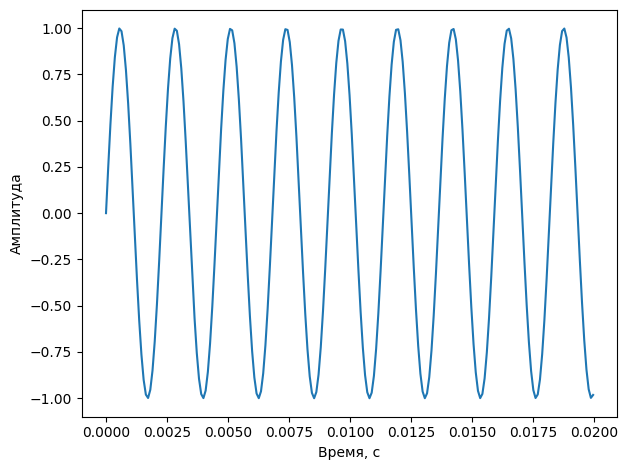

In [8]:
original_segment = original_wave.segment(start=0, duration=0.02)

original_segment.plot()
decorate(xlabel='Время, с', ylabel='Амплитуда')

## 5. Замедление сигнала

Создадим копию исходной волны и применим `stretch` с коэффициентом `2`.

Это должно растянуть сигнал во времени: звук станет медленнее и ниже.


In [9]:
slow_wave = original_wave.copy()
stretch(slow_wave, 2)

slow_wave.normalize()
slow_wave.make_audio()

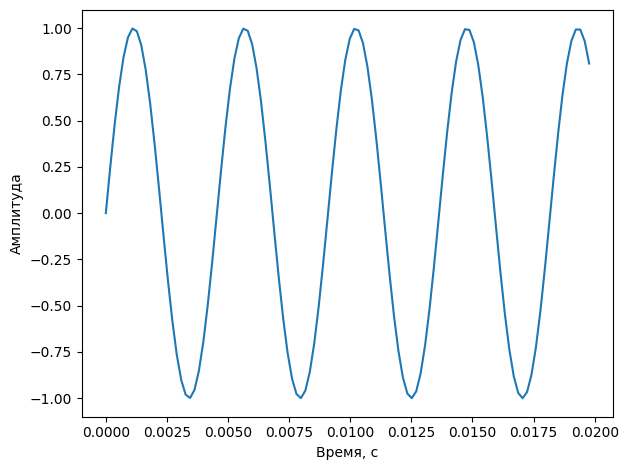

In [10]:
slow_segment = slow_wave.segment(start=0, duration=0.02)

slow_segment.plot()
decorate(xlabel='Время, с', ylabel='Амплитуда')

Сохраним замедленный сигнал в WAV-файл.


In [11]:
slow_wave.write('slow_440.wav')

Writing slow_440.wav


## 6. Ускорение сигнала

Создадим ещё одну копию исходной волны и применим `stretch` с коэффициентом `0.5`.

Это должно сжать сигнал во времени: звук станет быстрее и выше.


In [12]:
fast_wave = original_wave.copy()
stretch(fast_wave, 0.5)

fast_wave.normalize()
fast_wave.make_audio()

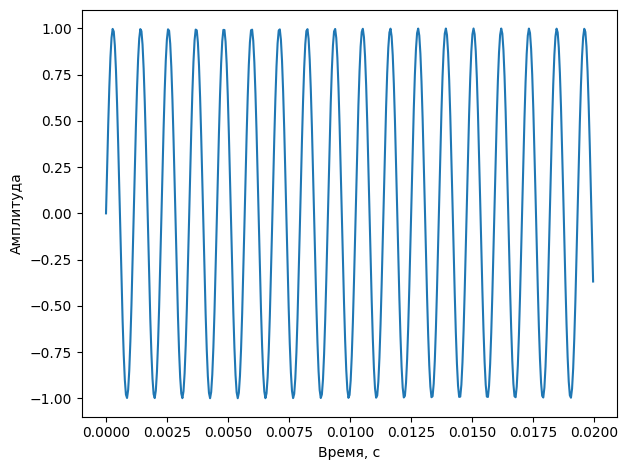

In [13]:
fast_segment = fast_wave.segment(start=0, duration=0.02)

fast_segment.plot()
decorate(xlabel='Время, с', ylabel='Амплитуда')

Сохраним ускоренный сигнал в WAV-файл.


In [14]:
fast_wave.write('fast_440.wav')

Writing fast_440.wav


## 7. Сравнение исходного, замедленного и ускоренного сигнала

Посмотрим на параметры трёх волн.


In [15]:
print('Исходный сигнал:')
print('framerate:', original_wave.framerate)
print('start:', original_wave.start)
print('end:', original_wave.end)
print('duration:', original_wave.duration)

print('\nЗамедленный сигнал:')
print('framerate:', slow_wave.framerate)
print('start:', slow_wave.start)
print('end:', slow_wave.end)
print('duration:', slow_wave.duration)

print('\nУскоренный сигнал:')
print('framerate:', fast_wave.framerate)
print('start:', fast_wave.start)
print('end:', fast_wave.end)
print('duration:', fast_wave.duration)

Исходный сигнал:
framerate: 11025
start: 0.0
end: 0.9999092970521541
duration: 1.0

Замедленный сигнал:
framerate: 5512.5
start: 0.0
end: 1.9998185941043083
duration: 2.0

Ускоренный сигнал:
framerate: 22050.0
start: 0.0
end: 0.4999546485260771
duration: 0.5


Построим спектр исходного сигнала.


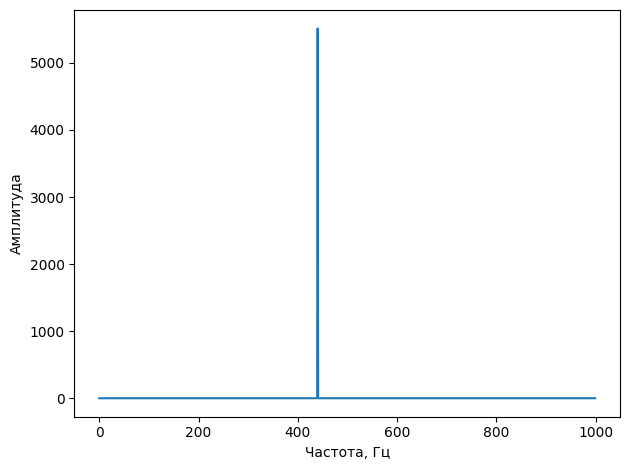

In [16]:
original_spectrum = original_wave.make_spectrum()
original_spectrum.plot(high=1000)
decorate(xlabel='Частота, Гц', ylabel='Амплитуда')

Построим спектр замедленного сигнала.


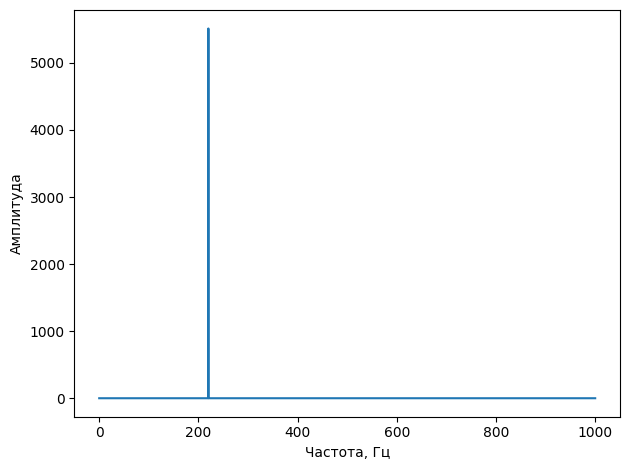

In [17]:
slow_spectrum = slow_wave.make_spectrum()
slow_spectrum.plot(high=1000)
decorate(xlabel='Частота, Гц', ylabel='Амплитуда')

Построим спектр ускоренного сигнала.


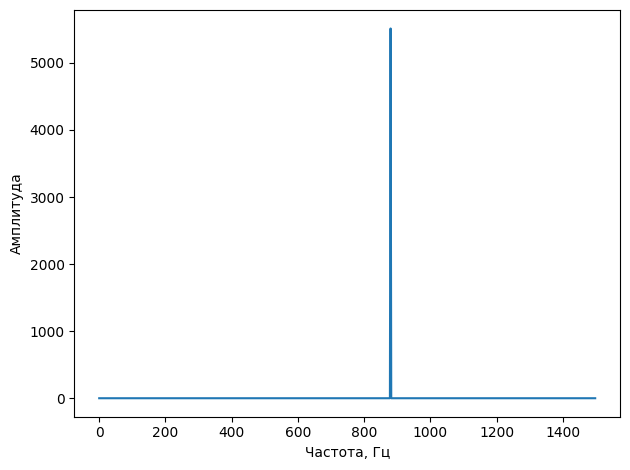

In [18]:
fast_spectrum = fast_wave.make_spectrum()
fast_spectrum.plot(high=1500)
decorate(xlabel='Частота, Гц', ylabel='Амплитуда')

## 8. Проверка результата

Для исходного сигнала основной пик находится около 440 Гц.

После замедления с `factor = 2` воспринимаемая частота должна стать примерно в 2 раза ниже, то есть около 220 Гц.

После ускорения с `factor = 0.5` воспринимаемая частота должна стать примерно в 2 раза выше, то есть около 880 Гц.


## Вывод

В упражнении 1.4 была написана функция `stretch`, которая изменяет временную шкалу сигнала и частоту дискретизации. Было проверено, что при коэффициенте `factor > 1` сигнал замедляется и звучит ниже, а при `factor < 1` сигнал ускоряется и звучит выше.

На примере синусоидального сигнала частотой 440 Гц было показано, что изменение `ts` и `framerate` влияет на скорость воспроизведения и воспринимаемую высоту звука. Таким образом, функция `stretch` позволяет управлять длительностью и звучанием объекта `Wave`.
